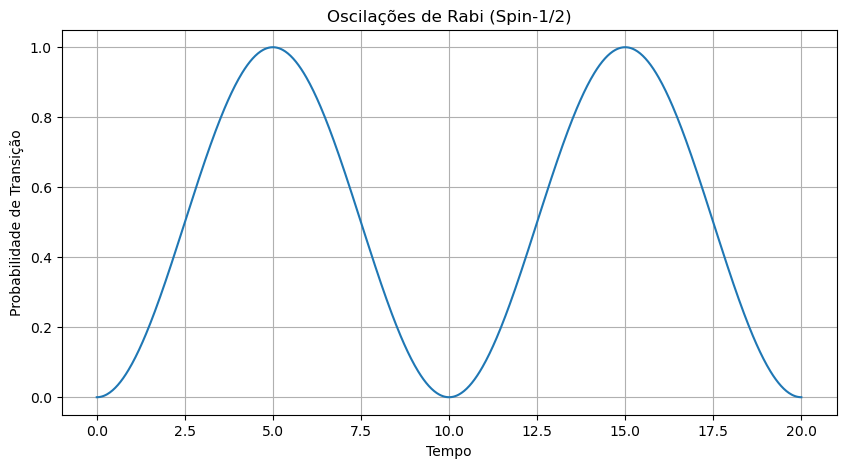

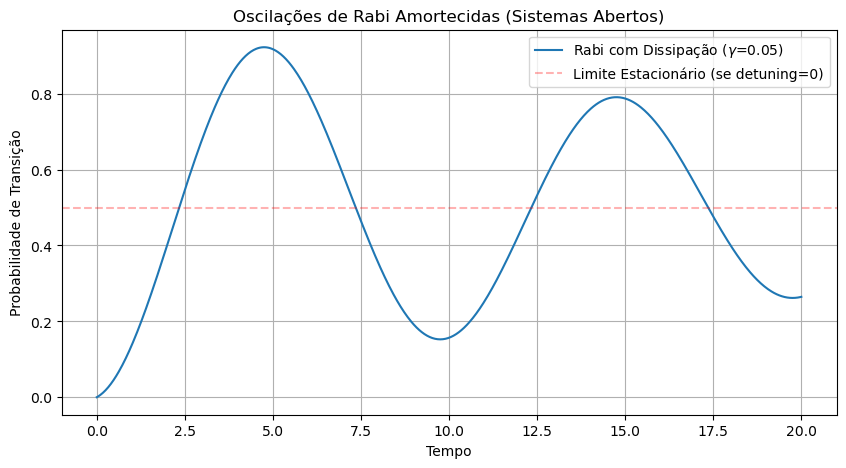

In [4]:
# teste inicial, sistema de spin 1/2, teoria cohen, teste de decoerencia.
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Parâmetros (ajuste para ver a ressonância)
omega0 = 1.0 * 2 * np.pi  # Frequência de Larmor (energia do sistema)
omega = 1.0 * 2 * np.pi   # Frequência do campo rotativo (ressonância: omega = omega0)
omega1 = 0.1 * 2 * np.pi  # Frequência de Rabi (força do acoplamento)

# Parâmetro de Dissipação (Taxa de decaimento T1)
gamma = 0.05  # Tente mudar para 0.2 para ver o "amortecimento" forte

times = np.linspace(0.0, 20.0, 801)

# Operadores e Estado Inicial (Spin para cima)
psi0 = basis(2, 0)
sx, sy, sz = sigmax(), sigmay(), sigmaz()

# Hamiltoniano dependente do tempo (Formato de lista de funções)
# H = H0 + H1_x * cos(wt) + H1_y * sin(wt)
h0 = (omega0 / 2.0) * sz
h1_x = (omega1 / 2.0) * sx
h1_y = (omega1 / 2.0) * sy

def tr_x(t, args): return np.cos(omega * t)
def tr_y(t, args): return np.sin(omega * t)

H = [h0, [h1_x, tr_x], [h1_y, tr_y]]

# Operadores de Colapso (o fundamento do sistema aberto)
# sigmam() é o operador de aniquilação (abaixamento) |1> -> |0>
# O fator np.sqrt(gamma) é necessário porque a taxa de transição é gamma
c_ops = [np.sqrt(gamma) * sigmam()]

# Evolução Temporal (Master Equation solver, Lindblad)
result1 = mesolve(H, psi0, times, [], [sz])
# Probabilidade de transição P(+ -> -) = (1 - <sigma_z>) / 2
p_minus = (1 - result1.expect[0]) / 2

# Visualização
plt.figure(figsize=(10,5))
plt.plot(times, p_minus, label="Simulação QuTiP")
plt.xlabel('Tempo')
plt.ylabel('Probabilidade de Transição')
plt.title('Oscilações de Rabi (Spin-1/2)')
plt.grid(True)
plt.show()

# ----------------------------------------------------------------------------
# com amortecimento
result2 = mesolve(H, psi0, times, c_ops, [sz])
p_minus = (1 - result2.expect[0]) / 2

plt.figure(figsize=(10,5))
plt.plot(times, p_minus, label=rf"Rabi com Dissipação ($\gamma$={gamma})")
plt.axhline(0.5, color='red', linestyle='--', alpha=0.3, label=r"Limite Estacionário (se detuning=0)")
plt.xlabel('Tempo')
plt.ylabel('Probabilidade de Transição')
plt.title('Oscilações de Rabi Amortecidas (Sistemas Abertos)')
plt.legend()
plt.grid(True)
plt.show()

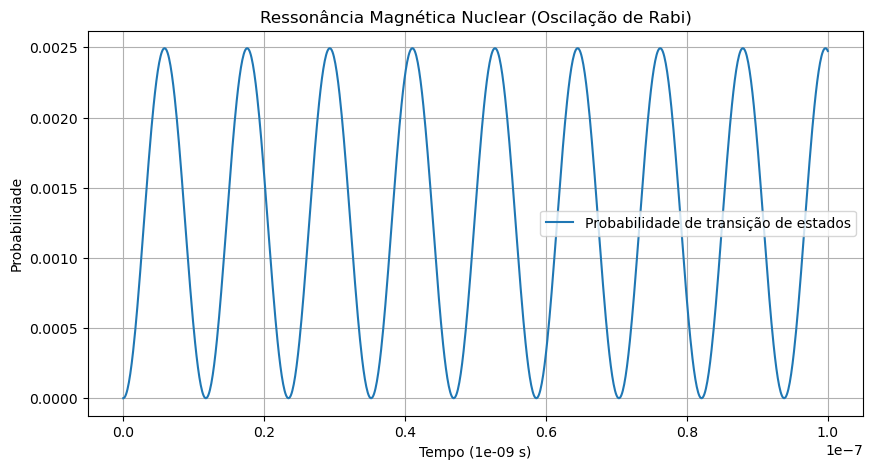

In [31]:
#teste com sistema de spin 1, núcleo do nitrogênio.
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

#Parâmetros (Ex: Centro NV ou Nitrogênio)
D = 2.87e9 * 2 * np.pi  # Desdobramento de campo zero (Hz -> rad/s)
gn = 1.76e11            # Razão giromagnética (ajuste conforme o núcleo)
B1 = 0.001              # Campo RF em Tesla
omega_rf = D            # Frequência de ressonância

# Exemplo para um Próton (H1)
gn = 5.585              # Fator g do próton
muN = 5.050e-27         # Magnéton nuclear (J/T)
hbar = 1.054e-34        # constante de Planck reduzida (J.s)
gamma_n = (gn * muN) / hbar # Razão giromagnética
#gamma_n ~ 2.675e8

# Normalização: Trabalhamos em unidades de frequência (MHz ou rad/s relativos)
# Em vez de usar J/T e J.s, definimos a escala pela razão giromagnética simplificada

#fatorEscala = 1e6
#gamma_n /= fatorEscala   # Ex: ~267 rad/(ms.T) para facilitar a escala do gráfico
B0 = 1.0
B1 = 0.1
#B1 = 0.01                 # Aumentei um pouco para a oscilação ser visível em 20 unidades de tempo

# Frequências resultantes (em rad/s)
omega0 = gamma_n * B0   
omega1 = gamma_n * B1   
omega = omega0          # Condição de ressonância exata

#escala = 1e-6  # Microssegundos
escala = 1e-9  # Nanossegundos
t_final = 100 * escala 
times = np.linspace(0, t_final, 1001)
#times = np.linspace(0.0, 0.5, 801) # Tempo reduzido para casar com a escala de MHz

# Em núcleo 14N, usar matrizes de Gell-Mann/Spin 1
# O Hamiltoniano H = -gamma * B . S
#sx, sy, sz = 0.5 * sigmax(), 0.5 * sigmay(), 0.5 * sigmaz()
sx, sy, sz = jmat(1, 'x'), jmat(1, 'y'), jmat(1, 'z')
psi0 = basis(3, 1)     # para S = 1 no qutip, o basis(3,1) eh o |0>. 

# Hamiltoniano (H = H0 + H_interação(t))
h0 = - omega0 * sz         
h1_x = - omega1 * sx       
h1_y = - omega1 * sy       

# Funções de tempo para o campo rotativo
def tr_x(t, args): return np.cos(omega * t)
def tr_y(t, args): return np.sin(omega * t)

H = [h0, [h1_x, tr_x], [h1_y, tr_y]]

# Evolução
# Usamos [sz] na lista de e_ops para obter o valor esperado de <Sz>
# Como Sz tem autovalores +0.5 e -0.5, a probabilidade P(-) é (0.5 - <Sz>)
result = mesolve(H, psi0, times, [], [sz])

# Cálculo da Probabilidade de Transição (Inversão de Spin)
# <Sz> varia de 0.5 (cima) a -0.5 (baixo). 
p_minus = 0.5 - result.expect[0] 

# Visualização
plt.figure(figsize=(10,5))
plt.plot(times, p_minus, label="Probabilidade de transição de estados")
plt.xlabel(f'Tempo ({escala} s)')
#plt.xlabel('Tempo (unidades normalizadas)')
plt.ylabel('Probabilidade')
plt.title('Ressonância Magnética Nuclear (Oscilação de Rabi)')
plt.grid(True)
plt.legend()
plt.show()


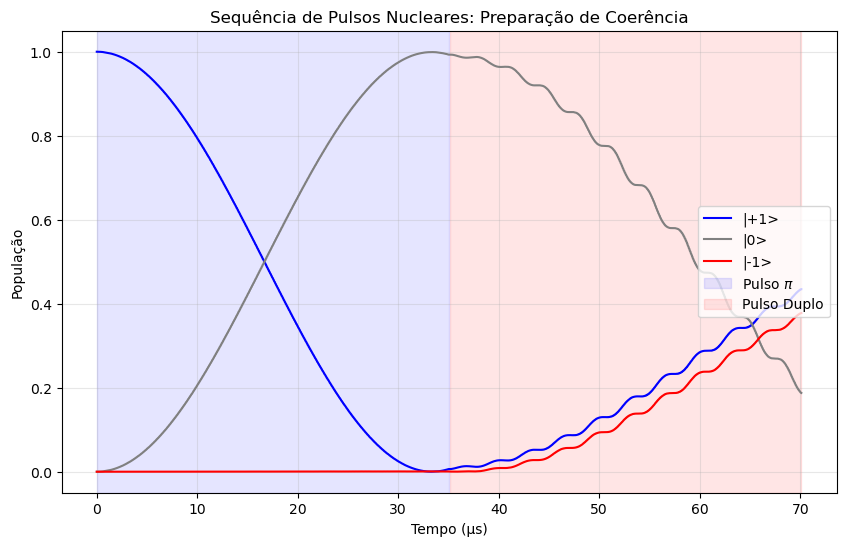

In [47]:
#refinando o modelo, fazendo transições de níveis.
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Parâmetros Físicos do 14N
# Frequências em MHz (trabalhar em MHz facilita a escala numérica)
Q = -4.94           # Interação Quadrupolar (MHz)
gamma_n = 3.077     # MHz/Tesla (Razão giromagnética do 14N)
gamma_e = 28024.9   # Razão giromagnética do elétron
B0 = 0.0482         # Campo estático (Tesla) - ex: 500 Gauss
D = 2870.0          # MHz (Desdobramento de campo zero do elétron)
A_perp = 2.7        # MHz (Acoplamento hiperfino transversal aproximado)

# Cálculo da frequência de transição nuclear corrigida (fórmula f_DQ)
# f_dq representa a separação entre |+1> e |-1>
termo_correcao = (gamma_e / gamma_n) * (A_perp**2 / (D**2 - (gamma_e * B0)**2))
f_dq = 2 * B0 * gamma_n * (1 - termo_correcao)

# Frequências da Sequência
f_pi = Q + f_dq * 0.5  # Transição |+1> -> |0> (Primeiro pulso)
f1 = Q + f_dq * 0.5    # Transição |0> -> |+1> (Parte do pulso duplo)
f2 = Q - f_dq * 0.5    # Transição |0> -> |-1> (Parte do pulso duplo)

# Tempos
t_p1 = 35.0           # Duração do primeiro pulso pi
t_gap = 0.1            # Pequeno intervalo entre pulsos
t_p2 = 35.0           # Duração do pulso duplo
t_final = t_p1 + t_gap + t_p2
times = np.linspace(0, t_final, 5000)

# Amplitudes (Calculadas para que 35us realize a rotação desejada)
# Para Spin 1, a freq. de Rabi é sqrt(2)*gamma*B1
fcalib = 2.1; # um termo de ajuste manual para reproduzir o comportamento esperado do sistema.
amp_pi = fcalib * 0.5 / (np.sqrt(2) * gamma_n * t_p1)
amp_duplo = (np.pi / np.sqrt(2)) / (2 * np.pi * gamma_n * t_p2)

#Definição das Funções de Pulso ---
def pulse_sequence(t, args):
    # Primeiro Pulso: |+1> -> |0>
    if 0 <= t <= t_p1:
        return amp_pi * np.cos(2 * np.pi * f_pi * t)
    
    # Segundo Pulso (Duplo): |0> -> |+1> e |-1>
    start_p2 = t_p1 + t_gap
    if start_p2 <= t <= (start_p2 + t_p2):
        t_rel = t - start_p2
        return amp_duplo * (np.cos(2 * np.pi * f1 * t_rel) + np.cos(2 * np.pi * f2 * t_rel))
    
    return 0.0

#Hamiltoniano e Simulação ---
ix, iy, iz = jmat(1, 'x'), jmat(1, 'y'), jmat(1, 'z')
psi0 = basis(3, 0) # Começa no estado |+1>

# H0 com níveis: |0> em zero, |+1> em Q + fdq/2, |-1> em Q - fdq/2
h0 = Q * (iz**2) + (f_dq / 2.0) * iz 
H = [2 * np.pi * h0, [-2 * np.pi * gamma_n * ix, pulse_sequence]]
result = mesolve(H, psi0, times, [], [])

# Populações
p_plus = [abs(st.overlap(basis(3, 0)))**2 for st in result.states]
p_zero = [abs(st.overlap(basis(3, 1)))**2 for st in result.states]
p_minus = [abs(st.overlap(basis(3, 2)))**2 for st in result.states]

# gráficos
plt.figure(figsize=(10, 6))
plt.plot(times, p_plus, label="|+1>", color='blue')
plt.plot(times, p_zero, label="|0>", color='gray')
plt.plot(times, p_minus, label="|-1>", color='red')

plt.axvspan(0, t_p1, color='blue', alpha=0.1, label=r"Pulso $\pi$")
plt.axvspan(t_p1+t_gap, t_final, color='red', alpha=0.1, label=r"Pulso Duplo")

plt.title('Sequência de Pulsos Nucleares: Preparação de Coerência')
plt.xlabel('Tempo (µs)')
plt.ylabel('População')
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.show()

/home/oeiras/miniconda3/lib/python3.13/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


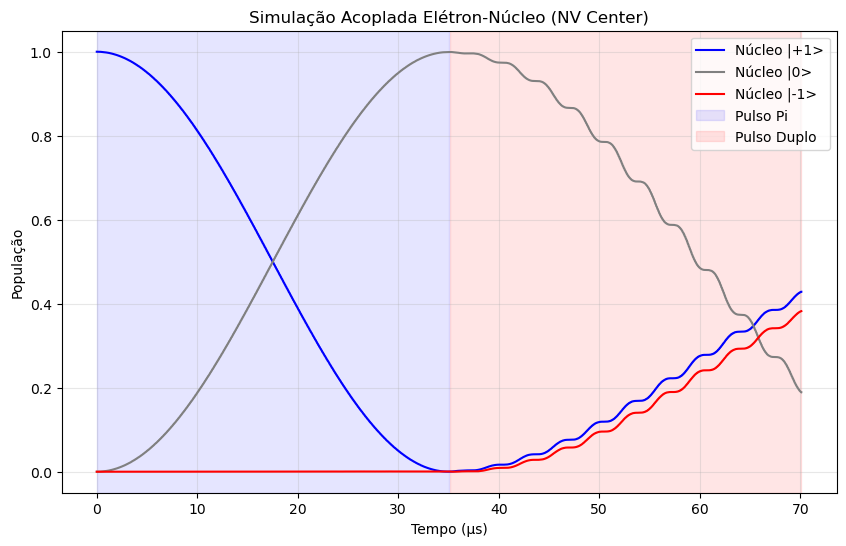

In [1]:
# modelo com acoplamento spin elétron e spin núcleo
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Parâmetros Físicos (MHz e us)
Q = -4.94           
gamma_n = 3.077     
gamma_e = 28024.9   
B0 = 0.0482         
D = 2870.0          
A_perp = 2.7        
A_zz = -2.14        # Acoplamento Hiperfino Longitudinal (MHz)

# Frequência corrigida para o núcleo (f_DQ)
termo_correcao = (gamma_e / gamma_n) * (A_perp**2 / (D**2 - (gamma_e * B0)**2))
f_dq = 2 * B0 * gamma_n * (1 - termo_correcao)

# Frequências da Sequência (Sintonizadas para quando o elétron está em m_s = 0)
f_pi = Q + f_dq * 0.5  
f1 = Q + f_dq * 0.5    
f2 = Q - f_dq * 0.5    

# Tempos e Amplitudes
t_p1, t_gap, t_p2 = 35.0, 0.1, 35.0
t_final = t_p1 + t_gap + t_p2
times = np.linspace(0, t_final, 5000)

fcalib = 1.414 # sqrt(2), ajuste teórico para Spin 1
amp_pi = fcalib * 0.5 / (gamma_n * t_p1) # Simplificado para teste
amp_duplo = (np.pi / np.sqrt(2)) / (2 * np.pi * gamma_n * t_p2)

# Operadores no Espaço Acoplado (6x6)
# Elétron (Spin 1/2 simplificado ou Spin 1) 
# Vamos usar Spin 1 para o elétron também, focando no subespaço |0> e |-1>
se_z = tensor(jmat(1, 'z'), qeye(3))
se_identity = tensor(qeye(3), qeye(3))

# Núcleo (Spin 1)
ix = tensor(qeye(3), jmat(1, 'x'))
iz = tensor(qeye(3), jmat(1, 'z'))

# Estado Inicial: Elétron em |0> e Núcleo em |+1>
# basis(3, 1) é m=0 | basis(3, 0) é m=+1
psi0 = tensor(basis(3, 1), basis(3, 0))

# Funções de Pulso
def pulse_sequence(t, args):
    if 0 <= t <= t_p1:
        return amp_pi * np.cos(2 * np.pi * f_pi * t)
    start_p2 = t_p1 + t_gap
    if start_p2 <= t <= (start_p2 + t_p2):
        t_rel = t - start_p2
        return amp_duplo * (np.cos(2 * np.pi * f1 * t_rel) + np.cos(2 * np.pi * f2 * t_rel))
    return 0.0

# Hamiltoniano da parte magnética
# H = H_elétron + H_núcleo + H_hiperfino
h_electron = D * se_z**2 + (gamma_e * B0) * se_z
h_nuclear = Q * iz**2 + (f_dq / 2.0) * iz
h_hyperfine = A_zz * se_z * iz

h0 = h_electron + h_nuclear + h_hyperfine
H = [2 * np.pi * h0, [-2 * np.pi * gamma_n * ix, pulse_sequence]]

# Simulação e Resultados
result = mesolve(H, psi0, times, [], [])

# Projetores para populações nucleares (independente do elétron)
p_plus = [expect(tensor(qeye(3), basis(3,0)*basis(3,0).dag()), st) for st in result.states]
p_zero = [expect(tensor(qeye(3), basis(3,1)*basis(3,1).dag()), st) for st in result.states]
p_minus = [expect(tensor(qeye(3), basis(3,2)*basis(3,2).dag()), st) for st in result.states]

# --- 6. Gráfico ---
plt.figure(figsize=(10, 6))
plt.plot(times, p_plus, label="Núcleo |+1>", color='blue')
plt.plot(times, p_zero, label="Núcleo |0>", color='gray')
plt.plot(times, p_minus, label="Núcleo |-1>", color='red')
plt.axvspan(0, t_p1, color='blue', alpha=0.1, label="Pulso Pi")
plt.axvspan(t_p1+t_gap, t_final, color='red', alpha=0.1, label="Pulso Duplo")
plt.title('Simulação Acoplada Elétron-Núcleo (NV Center)')
plt.xlabel('Tempo (µs)')
plt.ylabel('População')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [5]:
#Novo Bloco: Simulação de Sensibilidade à Rotação
def simular_rotacao(velocidade_rot):
    # h0 original + termo de rotação (Hz)
    # A rotação atua como um desvio de frequência no referencial do laboratório
    h_rot = velocidade_rot * iz 
    h_total_estatico = h0 + h_rot
    
    H_temp = [2 * np.pi * h_total_estatico, [-2 * np.pi * gamma_n * ix, pulse_sequence]]
    
    # Rodar a evolução (mesolve)
    # Usamos apenas o estado final para o gráfico de sensibilidade
    res = mesolve(H_temp, psi0, times, [], [])
    
    # Retorna a população final do estado |+1> (m_n = +1)
    pop_final_plus = expect(tensor(qeye(3), basis(3,0)*basis(3,0).dag()), res.states[-1])
    return pop_final_plus

# Varredura de velocidades de rotação (em MHz, por exemplo)
velocidades = np.linspace(-0.05, 0.05, 50) # Range de rotação para teste
sinal_sensor = [simular_rotacao(v) for v in velocidades]

ValueError: incompatible dimensions [[2], [2]] and [[3, 3], [3, 3]]

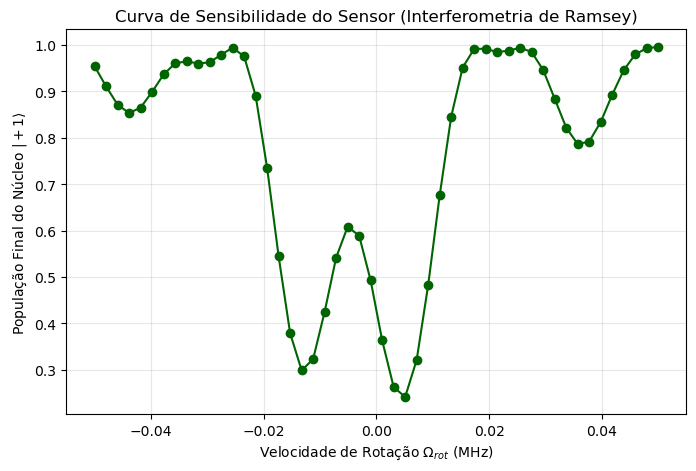

<Figure size 640x480 with 0 Axes>

In [6]:
#Gráfico de Sensibilidade (Franja de Interferência)
plt.figure(figsize=(8, 5))
plt.plot(velocidades, sinal_sensor, 'o-', color='darkgreen')
plt.title('Curva de Sensibilidade do Sensor (Interferometria de Ramsey)')
plt.xlabel(r"Velocidade de Rotação $\Omega_{rot}$ (MHz)")
plt.ylabel('População Final do Núcleo $|+1\\rangle$')
plt.grid(True, alpha=0.3)
plt.show()

import matplotlib
# Configurar o Matplotlib para usar LaTeX
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})
plt.savefig('grafico.pgf', bbox_inches='tight')


<>:23: SyntaxWarning: invalid escape sequence '\O'
<>:24: SyntaxWarning: invalid escape sequence '\O'
<>:23: SyntaxWarning: invalid escape sequence '\O'
<>:24: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_708361/2023362593.py:23: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(times, pop_sem, 'b--', label="Sem Rotação ($\Omega = 0$)")
/tmp/ipykernel_708361/2023362593.py:24: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(times, pop_com, 'r-', label=f"Com Rotação ($\Omega = {omega_teste}$ MHz)")


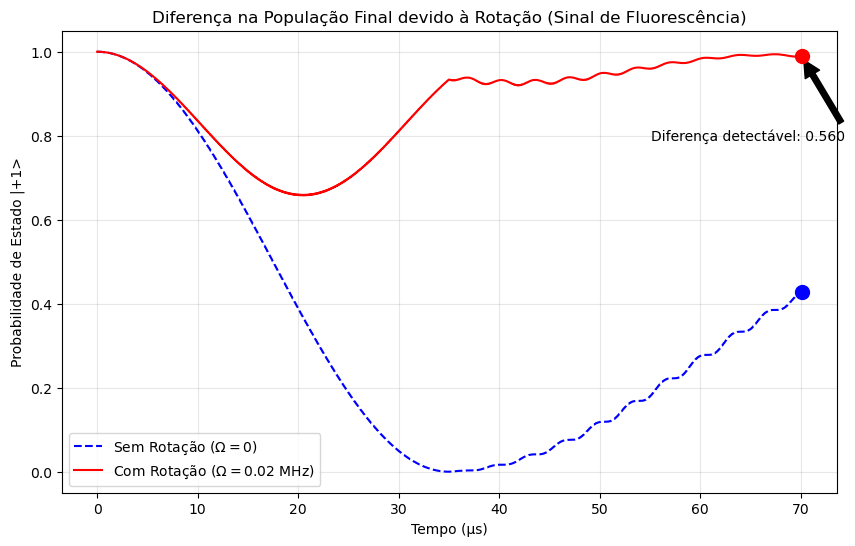

In [3]:
# Definindo as duas situações
omega_nula = 0.0
omega_teste = 0.02  # Uma rotação arbitrária para evidenciar o efeito

def rodar_experimento(omega):
    # Atualiza o Hamiltoniano com a rotação específica
    h_total = h0 + omega * iz 
    H_sim = [2 * np.pi * h_total, [-2 * np.pi * gamma_n * ix, pulse_sequence]]
    
    # Simulação da evolução temporal completa
    return mesolve(H_sim, psi0, times, [], [])

# Execução
res_sem_rot = rodar_experimento(omega_nula)
res_com_rot = rodar_experimento(omega_teste)

# Extração das populações do estado excitado nuclear |+1>
pop_sem = [expect(tensor(qeye(3), basis(3,0)*basis(3,0).dag()), st) for st in res_sem_rot.states]
pop_com = [expect(tensor(qeye(3), basis(3,0)*basis(3,0).dag()), st) for st in res_com_rot.states]

# --- 3. Gráfico de Evidência ---
plt.figure(figsize=(10, 6))
plt.plot(times, pop_sem, 'b--', label="Sem Rotação ($\Omega = 0$)")
plt.plot(times, pop_com, 'r-', label=f"Com Rotação ($\Omega = {omega_teste}$ MHz)")

# Marcar o ponto de leitura final
plt.scatter(times[-1], pop_sem[-1], color='blue', s=100, zorder=5)
plt.scatter(times[-1], pop_com[-1], color='red', s=100, zorder=5)

plt.annotate(f'Diferença detectável: {abs(pop_sem[-1]-pop_com[-1]):.3f}', 
             xy=(times[-1], pop_com[-1]), xytext=(times[-1]-15, pop_com[-1]-0.2),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Diferença na População Final devido à Rotação (Sinal de Fluorescência)')
plt.xlabel('Tempo (µs)')
plt.ylabel('Probabilidade de Estado |+1>')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Parte final deve ser excutada à parte, resultados até o momento.

f_pi: -4.793224309056718, f1: -5.086775690943282, f2: -4.793224309056718


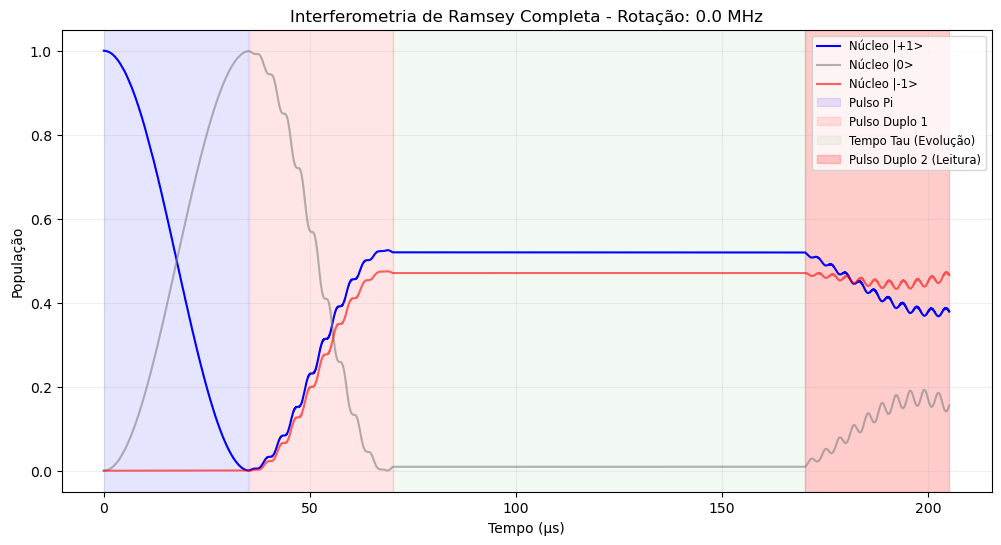

In [77]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Parâmetros Físicos do 14N
# Frequências em MHz (trabalhar em MHz facilita a escala numérica)
Q = -4.94           # Interação Quadrupolar (MHz)
gamma_n = 3.077     # MHz/Tesla (Razão giromagnética do 14N)
gamma_e = 28024.9   # Razão giromagnética do elétron
B0 = 0.0482         # Campo estático (Tesla) - ex: 500 Gauss
D = 2870.0          # MHz (Desdobramento de campo zero do elétron)
A_perp = 2.7        # MHz (Acoplamento hiperfino transversal aproximado - Broadway)
A_zz = -2.14        # MHz refere-se à componente longitudinal da constante de interação hiperfina

# Eq. do artigo do marjola
termo_correcao = (gamma_e / gamma_n) * (A_perp**2 / (D**2 - (gamma_e * B0)**2))
f_dq = 2 * B0 * gamma_n * (1 - termo_correcao)


f_pi = Q + f_dq * 0.5  

# f1: |+1> e f2: |-1>
f1 = Q - f_dq * 0.5
f2 = Q + f_dq * 0.5  
print(f"f_pi: {f_pi}, f1: {f1}, f2: {f2}")

# Definição de Tempos da Sequência (us)
t_laser = 0.0        # laser aplicado.
t_p1 = 35.0          # Primeiro Pulso (Pi)
t_gap = 0.1          # Intervalo curto
t_p2 = 35.0          # Segundo Pulso (Duplo)
t_tau = 100.0        # Tempo de interação com a rotação
t_p3 = 35.0          # Terceiro Pulso (Duplo de leitura)

# Novo tempo final somando as janelas de laser
t_final = t_laser + t_p1 + t_gap + t_p2 + t_tau + t_p3 + t_laser
times = np.linspace(0, t_final, 15000) # Aumentar pontos para precisão

# Amplitudes
amp_exp = 0.02 / gamma_n # MHz, por exp jarmola, para 35 us
fcalib = 1.414      # fator de calibração
#amp_pi = fcalib * 0.5 / (gamma_n * t_p1) 
#amp_duplo = (np.pi / np.sqrt(2)) / (2 * np.pi * gamma_n * t_p2)
amp_pi = 0.02 / gamma_n # para 35 us, se mudar t_p1, recalibrar
amp_duplo = 0.015 / gamma_n

# Operadores e Hamiltoniano Estático
se_z = tensor(jmat(1, 'z'), qeye(3))
ix = tensor(qeye(3), jmat(1, 'x'))
iy = tensor(qeye(3), jmat(1, 'y'))
iz = tensor(qeye(3), jmat(1, 'z'))

h_electron = D * se_z**2 + (gamma_e * B0) * se_z
h_nuclear = Q * iz**2 + (f_dq / 2.0) * iz
h_hyperfine = A_zz * se_z * iz
h_mag = h_electron + h_nuclear + h_hyperfine

# Funções de Controle (Pulsos e Rotação)
Omega_rot = 2 * np.pi * 5.0  # Frequência de rotação do sistema (kHz ou MHz)
def pulse_sequence(t, args):
    # 1. Primeiro Pulso (Pi)
    if 0 <= t <= t_p1:
        return amp_pi * np.cos(2 * np.pi * f_pi * t)
    
    # 2. Segundo Pulso (Duplo)
    fase = 0.   # np.pi # fase entre os pulsos
    start_p2 = t_p1 + t_gap
    if start_p2 <= t <= (start_p2 + t_p2):
        t_rel = t - start_p2
        return amp_duplo * (np.cos(2 * np.pi * f1 * t_rel) + np.cos(2 * np.pi * f2 * t_rel + fase))
    
    # 3. Terceiro Pulso (Duplo de Leitura) após o tempo Tau
    start_p3 = start_p2 + t_p2 + t_tau
    if start_p3 <= t <= (start_p3 + t_p3):
        t_rel = t - start_p3
        return amp_duplo * (np.cos(2 * np.pi * f1 * t_rel) + np.cos(2 * np.pi * f2 * t_rel + fase))
    
    return 0.0

def rotation_control(t, args):
    # Ativa a rotação apenas durante o tempo Tau
    start_tau = t_p1 + t_gap + t_p2
    if start_tau <= t <= (start_tau + t_tau):
        return args['omega_rot']
    return 0.0

# laser
def laser_on_off(t, args):
    # ini
    if t <= t_laser:
        return 1.0
    # fim
    start_read = t_laser + t_p1 + t_gap + t_p2 + t_tau + t_p3
    if t >= start_read:
        return 1.0
    return 0.0

# Simulação
# Definimos a rotação (em MHz). Mude para 0.0 para ver o sistema sem rotação.
#omega_val = 0.005 
omega_val = 0.0 

# Estado Inicial: Elétron em |0> e Núcleo em |+1>
# basis(3, 1) é m=0 | basis(3, 0) é m=+1
psi0 = tensor(basis(3, 1), basis(3, 0)).unit() # m_s=0, m_I=1

# Hamiltoniano: H_estatico + H_laser(t) + H_rotacao(t)
#H = [2 * np.pi * h_mag, 
#     [-2 * np.pi * gamma_n * ix, pulse_sequence],
#     [iz, rotation_control]]
# obs: termo de campo constante e o termo com dependencia temporal
H = [2 * np.pi * h_mag, [-2 * np.pi * gamma_n * ix, pulse_sequence]]

result = mesolve(H, psi0, times, [], [], args={'omega_rot': omega_val})

# Visualização
p_plus = [expect(tensor(qeye(3), basis(3,0)*basis(3,0).dag()), st) for st in result.states]
p_zero = [expect(tensor(qeye(3), basis(3,1)*basis(3,1).dag()), st) for st in result.states]
p_minus = [expect(tensor(qeye(3), basis(3,2)*basis(3,2).dag()), st) for st in result.states]

plt.figure(figsize=(12, 6))
plt.plot(times, p_plus, label="Núcleo |+1>", color='blue', lw=1.5)
plt.plot(times, p_zero, label="Núcleo |0>", color='gray', alpha=0.6)
plt.plot(times, p_minus, label="Núcleo |-1>", color='red', alpha=0.6)

# Sombreamento das fases
plt.axvspan(0, t_p1, color='blue', alpha=0.1, label="Pulso Pi")
plt.axvspan(t_p1+t_gap, t_p1+t_gap+t_p2, color='red', alpha=0.1, label="Pulso Duplo 1")
plt.axvspan(t_p1+t_gap+t_p2, t_p1+t_gap+t_p2+t_tau, color='green', alpha=0.05, label="Tempo Tau (Evolução)")
plt.axvspan(t_p1+t_gap+t_p2+t_tau, t_final, color='red', alpha=0.2, label="Pulso Duplo 2 (Leitura)")

plt.title(f'Interferometria de Ramsey Completa - Rotação: {omega_val} MHz')
plt.xlabel('Tempo (µs)')
plt.ylabel('População')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, alpha=0.2)
plt.show()

In [89]:
# obs: rodar o bloco acima antes
# Frequência de rotação simulada (Mashhoon)
# Definindo duas situações
omega_nula = 0.0
omega_teste = 0.01  # Uma rotação arbitrária para evidenciar o efeito

Omega_rot = omega_teste # 2 * np.pi * 5.0  # Frequência de rotação simulada (Mashhoon)
B1_mash = amp_duplo     # Amplitude do campo rotativo de simulação

#Definimos o início e o fim do intervalo tau
t_inicio_tau = t_laser + t_p1 + t_gap + t_p2
t_fim_tau = t_inicio_tau + t_tau

# executar
def rodar_experimento(omega_valor):
    # Definimos a função de controle para o termo de rotação Iz
    def lig_desl_rot(t, args):
        start_tau = t_p1 + t_gap + t_p2
        if start_tau <= t <= (start_tau + t_tau):
            return omega_valor # MHz
        return 0.0

    H_sim = [
        2 * np.pi * h_mag, 
        [iz, lig_desl_rot], # Efeito Mashhoon direto no eixo Z
        [-2 * np.pi * gamma_n * ix, pulse_sequence]
    ]    
    return mesolve(H_sim, psi0, times, [], [])


#H_sim = [        2 * np.pi * h_mag,         [2 * np.pi * omega * iz, pulso_rotacao],        [-2 * np.pi * gamma_n * ix, pulse_sequence]    ]    
    
# Execução
res_sem_rot = rodar_experimento(omega_nula)
res_com_rot = rodar_experimento(omega_teste)

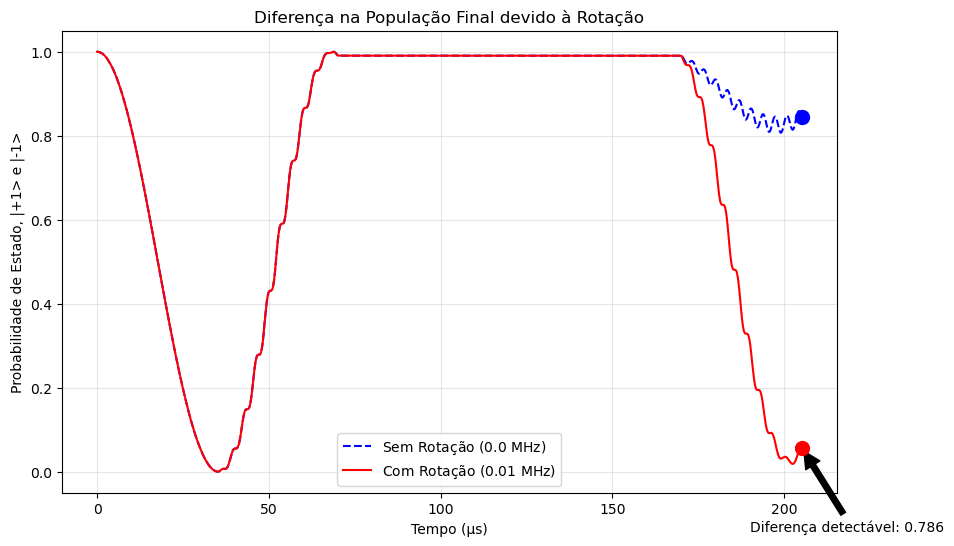

In [93]:
# Extração das populações do estado excitado nuclear |+1> e |-1>
pop_sem_p = [expect(tensor(qeye(3), basis(3,0)*basis(3,0).dag()), st) for st in res_sem_rot.states]
pop_sem_m = [expect(tensor(qeye(3), basis(3,2)*basis(3,2).dag()), st) for st in res_sem_rot.states]
pop_com_p = [expect(tensor(qeye(3), basis(3,0)*basis(3,0).dag()), st) for st in res_com_rot.states]
pop_com_m = [expect(tensor(qeye(3), basis(3,2)*basis(3,2).dag()), st) for st in res_com_rot.states]

# |0>
pop_sem_z = [expect(tensor(qeye(3), basis(3,1)*basis(3,1).dag()), st) for st in res_sem_rot.states]
pop_com_z = [expect(tensor(qeye(3), basis(3,1)*basis(3,1).dag()), st) for st in res_com_rot.states]

pop_sem = np.add(np.array(pop_sem_p),np.array(pop_sem_m))
pop_com = np.add(np.array(pop_com_p),np.array(pop_com_m))

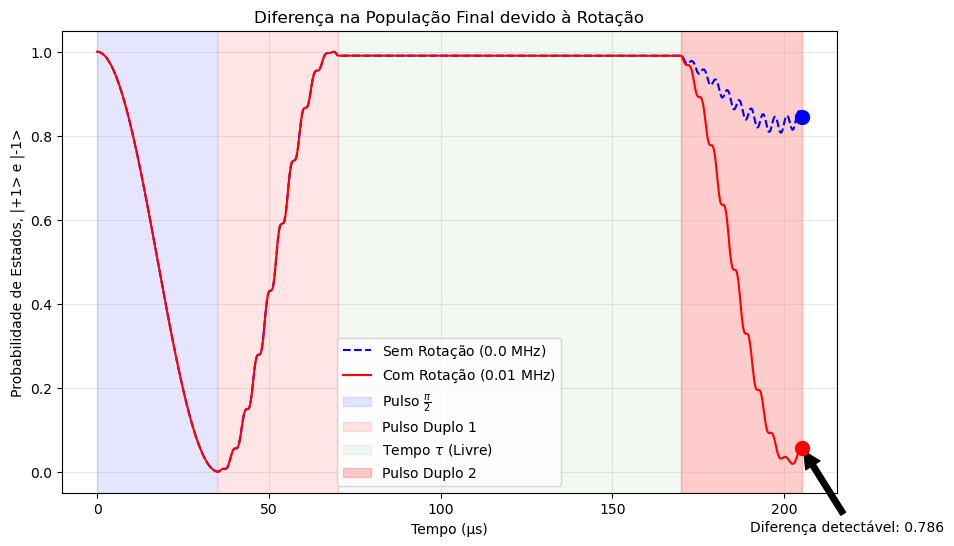

In [97]:
# Gráfico de Evidência
plt.figure(figsize=(10, 6))
plt.plot(times, pop_sem, 'b--', label=r"Sem Rotação (${0.0}$ MHz)")
plt.plot(times, pop_com, 'r-', label=rf"Com Rotação (${omega_teste}$ MHz)")

# Marcar o ponto de leitura final
plt.scatter(times[-1], pop_sem[-1], color='blue', s=100, zorder=5)
plt.scatter(times[-1], pop_com[-1], color='red', s=100, zorder=5)

plt.annotate(f'Diferença detectável: {abs(pop_sem[-1]-pop_com[-1]):.3f}', 
             xy=(times[-1], pop_com[-1]), xytext=(times[-1]-15, pop_com[-1]-0.2),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Sombreamento das fases
plt.axvspan(0, t_p1, color='blue', alpha=0.1, label=r"Pulso $\frac{\pi}{2}$")
plt.axvspan(t_p1+t_gap, t_p1+t_gap+t_p2, color='red', alpha=0.1, label="Pulso Duplo 1")
plt.axvspan(t_p1+t_gap+t_p2, t_p1+t_gap+t_p2+t_tau, color='green', alpha=0.05, label=r"Tempo $\tau$ (Livre)")
plt.axvspan(t_p1+t_gap+t_p2+t_tau, t_final, color='red', alpha=0.2, label="Pulso Duplo 2")

plt.title('Diferença na População Final devido à Rotação')
plt.xlabel('Tempo (µs)')
plt.ylabel('Probabilidade de Estados, |+1> e |-1>')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()